# Bài tập thực hành tuần 3
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Chiều thứ 6, ca 1)

Import các thư viện cần thiết

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.decomposition import PCA

### 1. Viết chương trình tính khoảng cách edit

In [175]:
def find_minimum_edit_distance(source_string, target_string):
    # Khởi tạo ma trận DP với kích thước (len(target_string) + 1) x (len(source_string) + 1) và giá trị 0
    dp = [[0]*(len(source_string) + 1) for i in range(len(target_string) + 1)]
    
    # Điền giá trị ban đầu cho cột đầu tiên của ma trận DP
    for i in range(1, len(target_string) + 1):
        dp[i][0] = dp[i - 1][0] + 1
    
    # Điền giá trị ban đầu cho hàng đầu tiên của ma trận DP
    for i in range(1, len(source_string) + 1):
        dp[0][i] = dp[0][i - 1] + 1
    
    # Khởi tạo danh sách các phép biến đổi chuỗi để từ chuỗi nguồn biến thành chuỗi đích
    operations_performed = []
    
    # Tính giá trị của ma trận DP bằng cách so sánh kí tự tại vị trí i-1 của chuỗi đích và j-1 của chuỗi nguồn
    # Nếu hai kí tự bằng nhau thì lấy giá trị ở ô bên trên và bên trái, nếu khác nhau thì lấy giá trị tối thiểu của 
    # ba ô bên trên, bên trái, và bên trên trái cộng thêm 1 hoặc 2 (tương ứng với phép thay thế và phép xoá/chèn)
    for i in range(1, len(target_string) + 1):
        for j in range(1, len(source_string) + 1):
            if source_string[j - 1] == target_string[i-1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                dp[i][j] = min(dp[i - 1][j] + 1,
                               dp[i - 1][j - 1] + 2,
                               dp[i][j - 1] + 1)
    
    # Truy vết ngược lại từ ô cuối cùng của ma trận DP đến ô đầu tiên để xác định danh sách các phép biến đổi
    # để từ chuỗi nguồn biến thành chuỗi đích
    i = len(target_string)
    j = len(source_string)
    while (i != 0 and j != 0):
        if target_string[i-1] == source_string[j-1]:
            i -= 1
            j -= 1
        else:
            if dp[i][j] == dp[i - 1][j - 1]+2:
                operations_performed.append(
                    ('SUBSTITUTE', source_string[j-1], target_string[i - 1]))
                i -= 1
                j -= 1
            elif dp[i][j] == dp[i - 1][j]+1:
                operations_performed.append(('INSERT', target_string[i - 1]))
                i -= 1
            else:
                operations_performed.append(('DELETE', source_string[j - 1]))
                j -= 1
    # Xóa các kí tự còn lại của chuỗi nguồn
    while (j != 0):
        operations_performed.append(('DELETE', source_string[j-1]))
        j -= 1
    # Chèn các kí tự còn lại cho chuỗi đích
    while (i != 0):
        operations_performed.append(('INSERT', target_string[i-1]))
        i -= 1
    # Đảo ngược danh sách operation_performed
    operations_performed.reverse()
    return [dp[len(target_string)][len(source_string)], operations_performed]

In [176]:
input1 = "rizz"
target1= "rizzler"
print(find_minimum_edit_distance(input1, target1))

input2 = "skibidi"
target2 = "skib"
print(find_minimum_edit_distance(input2, target2))

input3 = "bruh"
target3 = "brah"
print(find_minimum_edit_distance(input3, target3))

input4 = "sus"
target4 = "buss"
print(find_minimum_edit_distance(input4, target4))

input6 = "wibu"
target6 = "simp"
print(find_minimum_edit_distance(input6, target6))

input7 = "sigma"
target7 = "ligma"
print(find_minimum_edit_distance(input7, target7))

[3, [('INSERT', 'l'), ('INSERT', 'e'), ('INSERT', 'r')]]
[3, [('DELETE', 'i'), ('DELETE', 'd'), ('DELETE', 'i')]]
[2, [('SUBSTITUTE', 'u', 'a')]]
[3, [('SUBSTITUTE', 's', 'b'), ('INSERT', 's')]]
[6, [('SUBSTITUTE', 'w', 's'), ('SUBSTITUTE', 'b', 'm'), ('SUBSTITUTE', 'u', 'p')]]
[2, [('SUBSTITUTE', 's', 'l')]]


### 2. Viết chương trình tính khoảng cách dãy con chung dài nhất

In [177]:
def LCSS(start, end):
    m = len(start)
    n = len(end)

    dp = [[0] * (m + 1) for _ in range(n + 1)]
    common_string = ''

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if start[j - 1] == end[i - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
                
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])

    i = n
    j = m
    while i != 0 and j != 0:
        if start[j - 1] == end[i - 1]:
            common_string += start[j - 1]
            i -= 1
            j -= 1
            
        elif dp[i - 1][j] > dp[i][j - 1]:
            i -= 1
            
        else:
            j -= 1

    return dp[n][m], common_string[::-1]

In [178]:
input1 = "skibidi"
target1 = "skibidi"
print(LCSS(input1, target1))

input2 = "sigma"
target2 = "uwu"
print(LCSS(input2, target2))

input3 = "ohio"
target3 = "bro"
print(LCSS(input3, target3))

input4 = "bussin"
target4 = "sussy"
print(LCSS(input4, target4))

input5 = "wompwomp"
target5 = "womp womp"
print(LCSS(input5, target5))

input6 = "mao mao"
target6 = "lmao"
print(LCSS(input6, target6))

input7 = "sigma"
target7 = "ligmaballs"
print(LCSS(input7, target7))

(7, 'skibidi')
(0, '')
(1, 'o')
(3, 'uss')
(8, 'wompwomp')
(3, 'mao')
(4, 'igma')


### 3. Tính khoảng cách biến đổi thời gian động

In [179]:
def DTW(series_1, series_2):
    m = len(series_1)
    n = len(series_2)
    
    if m == 0 or n == 0:
        return [], []
        
    dp = [[0]*n for i in range(m)]
    dp[0][0] = abs(series_1[0] - series_2[0])
    
    for i in range(1, m):
        dp[i][0] = abs(series_1[i] - series_2[0]) + dp[i-1][0]
    for i in range(1, n):
        dp[0][i] = abs(series_2[i] - series_1[0]) + dp[0][i-1]

    for i in range(1, m):
        for j in range(1, n):
            dp[i][j] = abs(series_1[i] - series_2[j]) + \
                min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])

    dp = dp[::-1]

    i = 0
    j = n-1
    warp_path = [(i, j)]
    
    while i != m-1 and j != 0:
        if min(dp[i+1][j], dp[i][j-1], dp[i+1][j-1]) == dp[i+1][j-1]:
            warp_path.append((i+1, j-1))
            i += 1
            j -= 1
        elif min(dp[i+1][j], dp[i][j-1], dp[i+1][j-1]) == dp[i+1][j]:
            warp_path.append((i+1, j))
            i += 1
        else:
            warp_path.append((i, j-1))
            j -= 1

    warp_path.append((m-1, 0))
    
    return dp, warp_path

In [180]:
def plotpath(cost_matrix, warp_path):
    cost_matrix = np.array(cost_matrix)
    rows, cols = cost_matrix.shape

    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(cost_matrix, cmap="Reds")

    threshold = cost_matrix.max() / 2.0
    for i in range(rows):
        for j in range(cols):
            val = cost_matrix[i, j]
            text_color = "white" if val > threshold else "black"
            ax.text(j, i, str(val), ha="center", va="center", color=text_color)

    ax.set_xticks(np.arange(-.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-.5, rows, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xticks(np.arange(cols))
    ax.set_yticks(np.arange(rows))

    path_x = [p[1] for p in warp_path]
    path_y = [p[0] for p in warp_path]

    ax.plot(path_x, path_y, color='blue', linewidth=3, alpha=0.5)
    plt.show()

([[1]], [(0, 0), (0, 0)])
([], [])


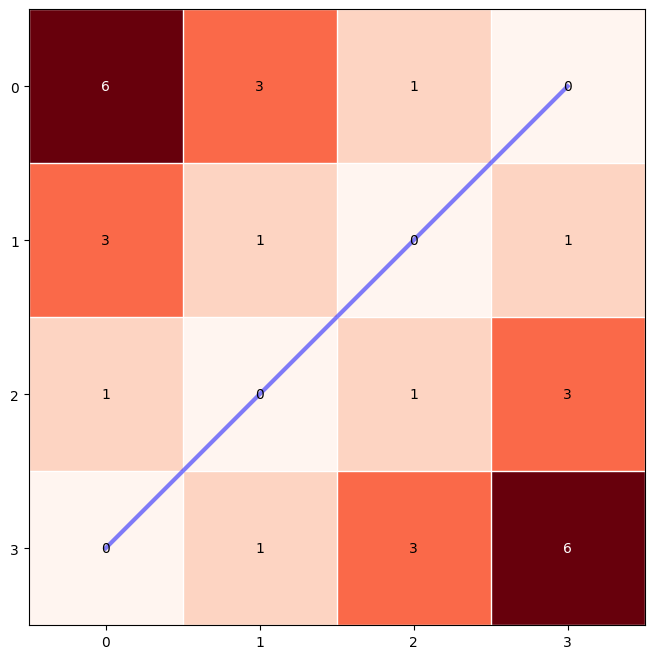

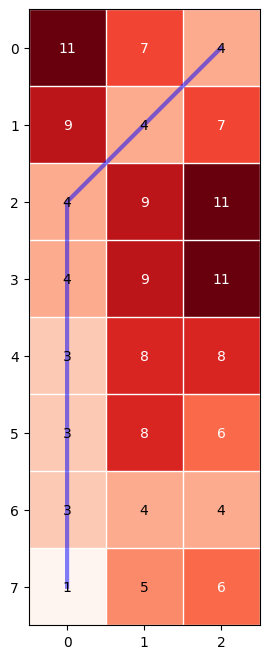

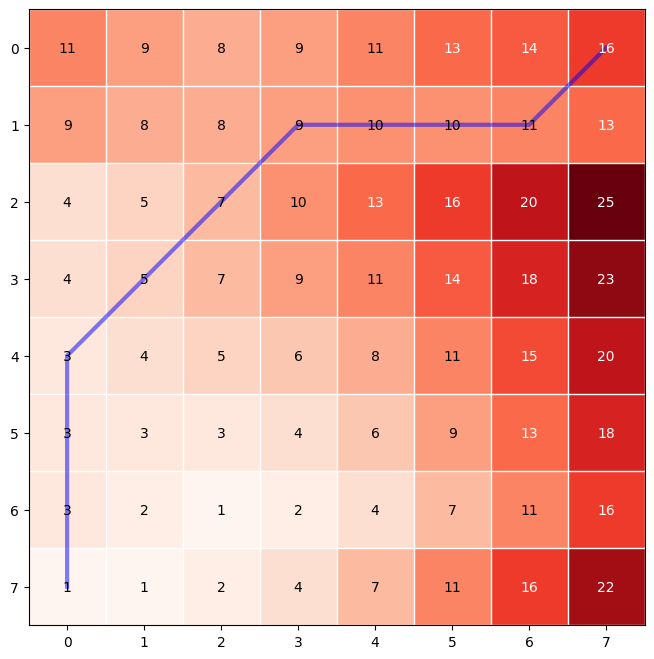

In [181]:
s1 = [1]
s2 = [2]
print(DTW(s1, s2))

s1 = []
s2 = [1, 2, 3, 4]
print(DTW(s1, s2))

s1 = [1, 2, 3, 4]
s2 = [1, 2, 3, 4]
cost_matrix, warp_path = DTW(s1, s2)
plotpath(cost_matrix, warp_path)

s1 = [1, 2, 3, 4]
s2 = [5, 6, 7, 8 , 9]
cost_matrix, warp_path = DTW(s1, s2)

s1 = [2, 3, 1, 1, 0, 1, 6 ,3]
s2 = [1, 6, 3]
cost_matrix, warp_path = DTW(s1, s2)
plotpath(cost_matrix, warp_path)

s1 = [2, 3, 1, 1, 0, 1, 6 ,3]
s2 = [1, 2, 3, 4, 5, 6, 7, 8]
cost_matrix, warp_path = DTW(s1, s2)
plotpath(cost_matrix, warp_path)